Using device: cuda


tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/464 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of ErnieForSequenceClassification were not initialized from the model checkpoint at nghuyong/ernie-2.0-base-en and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1: Train Loss = 1.7855, Train Acc = 0.6641, Test Loss = 0.6556, Test Acc = 0.8228
Epoch 2: Train Loss = 0.5896, Train Acc = 0.8313, Test Loss = 0.5178, Test Acc = 0.8402
Epoch 3: Train Loss = 0.4832, Train Acc = 0.8464, Test Loss = 0.4663, Test Acc = 0.8477
Epoch 4: Train Loss = 0.4384, Train Acc = 0.8526, Test Loss = 0.4519, Test Acc = 0.8477
Epoch 5: Train Loss = 0.4099, Train Acc = 0.8571, Test Loss = 0.4329, Test Acc = 0.8505

Total Training Time: 24667.15 seconds


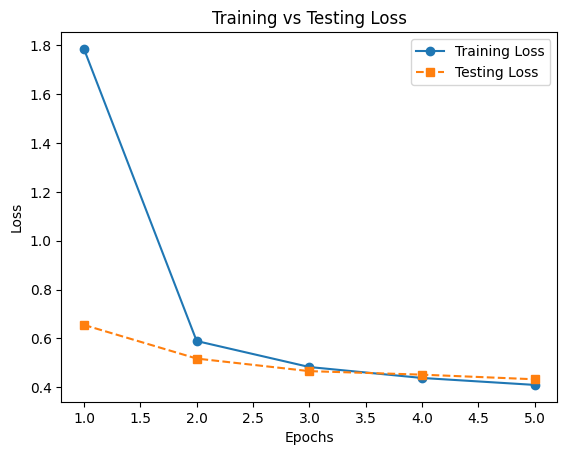

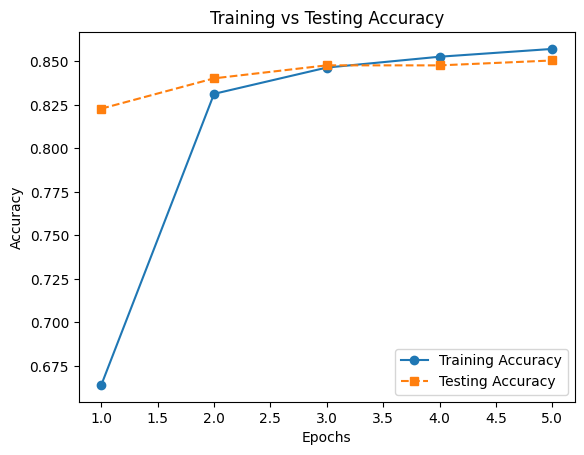


Classification Report:
                                                          precision    recall  f1-score   support

                               abdominal aortic aneurysm       0.91      1.00      0.95        20
                                        abdominal hernia       0.93      0.95      0.94        81
                                         abscess of nose       0.86      0.84      0.85        58
                                     abscess of the lung       1.00      0.83      0.91         6
                                  abscess of the pharynx       0.87      0.95      0.91        63
                                    acanthosis nigricans       0.86      1.00      0.92         6
                                               acariasis       1.00      0.80      0.89         5
                                               achalasia       0.67      1.00      0.80        20
                                                    acne       0.85      0.73      0.79      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load dataset
dataset_path = "/kaggle/input/diseases-and-symptoms-dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv"
df = pd.read_csv(dataset_path)

# Encode disease labels to numerical values
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['diseases'])

# Convert symptoms to text descriptions
df['text_description'] = df.drop(columns=['diseases', 'label']).apply(lambda row: ' '.join(row.index[row == 1]), axis=1)

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(df['text_description'], df['label'], test_size=0.2, random_state=42)

# Load ERNIE tokenizer
tokenizer = AutoTokenizer.from_pretrained("nghuyong/ernie-2.0-base-en")

# Custom dataset class
class SymptomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt"
        )
        return {key: val.squeeze(0) for key, val in encoding.items()}, torch.tensor(self.labels[idx])

# Create DataLoaders
train_dataset = SymptomDataset(X_train, y_train, tokenizer)
test_dataset = SymptomDataset(X_test, y_test, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Load ERNIE model for classification
model = AutoModelForSequenceClassification.from_pretrained("nghuyong/ernie-2.0-base-en", num_labels=len(label_encoder.classes_))
model.to(device)

# Define optimizer and loss function
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

# Train the model
num_epochs = 5
train_loss_values = []
test_loss_values = []
train_accuracies = []
test_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.to(device)

        outputs = model(**inputs)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        predictions = torch.argmax(outputs.logits, dim=1)
        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = total_train_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    # Validation Phase
    model.eval()
    total_test_loss = 0
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = {key: val.to(device) for key, val in inputs.items()}
            labels = labels.to(device)

            outputs = model(**inputs)
            loss = criterion(outputs.logits, labels)

            total_test_loss += loss.item()
            predictions = torch.argmax(outputs.logits, dim=1)
            correct_test += (predictions == labels).sum().item()
            total_test += labels.size(0)

    avg_test_loss = total_test_loss / len(test_loader)
    test_accuracy = correct_test / total_test

    train_loss_values.append(avg_train_loss)
    test_loss_values.append(avg_test_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Train Acc = {train_accuracy:.4f}, Test Loss = {avg_test_loss:.4f}, Test Acc = {test_accuracy:.4f}")

end_time = time.time()
print(f"\nTotal Training Time: {end_time - start_time:.2f} seconds")

# Plot training vs testing loss
plt.plot(range(1, num_epochs+1), train_loss_values, marker='o', linestyle='-', label="Training Loss")
plt.plot(range(1, num_epochs+1), test_loss_values, marker='s', linestyle='--', label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Testing Loss")
plt.legend()
plt.show()

# Plot training vs testing accuracy
plt.plot(range(1, num_epochs+1), train_accuracies, marker='o', linestyle='-', label="Training Accuracy")
plt.plot(range(1, num_epochs+1), test_accuracies, marker='s', linestyle='--', label="Testing Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()
plt.show()

# Evaluate the model
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.to(device)

        outputs = model(**inputs)
        predictions = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

# Print classification report with correct labels
print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=np.arange(len(label_encoder.classes_)), target_names=label_encoder.classes_))


In [7]:
from sklearn.metrics import classification_report
import numpy as np

# Ensure y_true and y_pred exist
if 'y_true' not in locals() or 'y_pred' not in locals():
    raise ValueError("y_true and y_pred are not defined. Run model evaluation first.")

# Find unique classes present in predictions
unique_classes = np.unique(y_true + y_pred)

# Print classification report using only the present labels
print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=unique_classes, target_names=label_encoder.inverse_transform(unique_classes)))



Classification Report:
                                                          precision    recall  f1-score   support

                               abdominal aortic aneurysm       0.91      1.00      0.95        20
                                        abdominal hernia       0.93      0.95      0.94        81
                                         abscess of nose       0.86      0.84      0.85        58
                                     abscess of the lung       1.00      0.83      0.91         6
                                  abscess of the pharynx       0.87      0.95      0.91        63
                                    acanthosis nigricans       0.86      1.00      0.92         6
                                               acariasis       1.00      0.80      0.89         5
                                               achalasia       0.67      1.00      0.80        20
                                                    acne       0.85      0.73      0.79      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import time
from transformers import T5Tokenizer, T5ForConditionalGeneration
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cuda


In [2]:
# Load dataset
dataset_path = "/kaggle/input/diseases-and-symptoms-dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv"
df = pd.read_csv(dataset_path)

# Encode disease labels to numerical values
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['diseases'])


In [5]:
# Convert symptoms to text descriptions
df['text_description'] = df.drop(columns=['diseases', 'label']).apply(lambda row: ' '.join(row.index[row == 1]), axis=1)

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(df['text_description'], df['label'], test_size=0.2, random_state=42)

# Load ERNIE tokenizer
tokenizer = AutoTokenizer.from_pretrained("nghuyong/ernie-2.0-base-en")


NameError: name 'AutoTokenizer' is not defined

In [ ]:
# Custom dataset class
class SymptomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt"
        )
        return {key: val.squeeze(0) for key, val in encoding.items()}, torch.tensor(self.labels[idx])

# Create DataLoaders
train_dataset = SymptomDataset(X_train, y_train, tokenizer)
test_dataset = SymptomDataset(X_test, y_test, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)



In [ ]:
# Load ERNIE model for classification
model = AutoModelForSequenceClassification.from_pretrained("nghuyong/ernie-2.0-base-en", num_labels=len(label_encoder.classes_))
model.to(device)

# Define optimizer and loss function
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)



In [ ]:
# Train the model
num_epochs = 5
train_loss_values = []
test_loss_values = []
train_accuracies = []
test_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.to(device)

        outputs = model(**inputs)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        predictions = torch.argmax(outputs.logits, dim=1)
        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = total_train_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    # Validation Phase
    model.eval()
    total_test_loss = 0
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = {key: val.to(device) for key, val in inputs.items()}
            labels = labels.to(device)

            outputs = model(**inputs)
            loss = criterion(outputs.logits, labels)

            total_test_loss += loss.item()
            predictions = torch.argmax(outputs.logits, dim=1)
            correct_test += (predictions == labels).sum().item()
            total_test += labels.size(0)

    avg_test_loss = total_test_loss / len(test_loader)
    test_accuracy = correct_test / total_test

    train_loss_values.append(avg_train_loss)
    test_loss_values.append(avg_test_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Train Acc = {train_accuracy:.4f}, Test Loss = {avg_test_loss:.4f}, Test Acc = {test_accuracy:.4f}")

end_time = time.time()
print(f"\nTotal Training Time: {end_time - start_time:.2f} seconds")



In [ ]:
# Plot training vs testing loss
plt.plot(range(1, num_epochs+1), train_loss_values, marker='o', linestyle='-', label="Training Loss")
plt.plot(range(1, num_epochs+1), test_loss_values, marker='s', linestyle='--', label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Testing Loss")
plt.legend()
plt.show()

# Plot training vs testing accuracy
plt.plot(range(1, num_epochs+1), train_accuracies, marker='o', linestyle='-', label="Training Accuracy")
plt.plot(range(1, num_epochs+1), test_accuracies, marker='s', linestyle='--', label="Testing Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()
plt.show()

# Evaluate the model
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.to(device)

        outputs = model(**inputs)
        predictions = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))
